In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RAW = '../data/raw/'
PROCESSED = '../data/processed/'
FINAL = '../data/final/'
FIGURES = '../outputs/figures/'
TABLES = '../outputs/tables/'


df = pd.read_csv(FINAL + 'dataset_barrios_clusters.csv')


In [11]:
#Selección de variables en el índica

#Variables de nivel (1/3 del peso en cada dimensión)
vars_nivel = {
    'pct_extranjera_2044': True,   # True = más alto es más gentrificado
    'pct_pob_2044': True,
    'pct_hosteleria_2023': True,
    'alquiler_2023': True,
    'pct_65mas': False             # False = más alto es MENOS gentrificado
}

#Variables de variación (2/3 del peso en cada dimensión)
vars_variacion = {
    'var_extranjera_2044_1823': True,
    'var_pob_2044_1823': True,
    'var_hosteleria_1823': True,
    'var_alquiler_dist_1823': True,
    'var_65mas_1823': False        # Más envejecimiento = menos gentrificación
}

print('Variables del índice:')
print(f'Nivel:{list(vars_nivel.keys())}')
print(f'Variación:{list(vars_variacion.keys())}')
print(f'\nTotal dimensiones: {len(vars_nivel)}')

Variables del índice:
Nivel:['pct_extranjera_2044', 'pct_pob_2044', 'pct_hosteleria_2023', 'alquiler_2023', 'pct_65mas']
Variación:['var_extranjera_2044_1823', 'var_pob_2044_1823', 'var_hosteleria_1823', 'var_alquiler_dist_1823', 'var_65mas_1823']

Total dimensiones: 5


In [12]:
#Función para normalizar entre 0 y 1
def normalizar(serie, positivo=True):
    """
    Normaliza una serie entre 0 y 1.
    positivo=True: mayor valor = mayor puntuación (más gentrificado)
    positivo=False: mayor valor = menor puntuación (menos gentrificado)
    """
    min_val = serie.min()
    max_val = serie.max()
    
    if max_val == min_val:
        return pd.Series([0.5] * len(serie), index=serie.index)
    
    normalizada = (serie - min_val) / (max_val - min_val)
    
    if not positivo:
        normalizada = 1 - normalizada
    
    return normalizada

#Normalizamos todas las variables
df_idx = df.copy()

# Normalizar variables de nivel
for var, positivo in vars_nivel.items():
    col_norm = f'{var}_norm'
    df_idx[col_norm] = normalizar(df_idx[var], positivo)
    print(f'{var} → {col_norm} (min:{df_idx[col_norm].min():.2f}, max:{df_idx[col_norm].max():.2f})')

print()

#Normalizamos las variables de variación
for var, positivo in vars_variacion.items():
    col_norm = f'{var}_norm'
    df_idx[col_norm] = normalizar(df_idx[var], positivo)
    print(f'{var} → {col_norm} (min:{df_idx[col_norm].min():.2f}, max:{df_idx[col_norm].max():.2f})')

pct_extranjera_2044 → pct_extranjera_2044_norm (min:0.00, max:1.00)
pct_pob_2044 → pct_pob_2044_norm (min:0.00, max:1.00)
pct_hosteleria_2023 → pct_hosteleria_2023_norm (min:0.00, max:1.00)
alquiler_2023 → alquiler_2023_norm (min:0.00, max:1.00)
pct_65mas → pct_65mas_norm (min:0.00, max:1.00)

var_extranjera_2044_1823 → var_extranjera_2044_1823_norm (min:0.00, max:1.00)
var_pob_2044_1823 → var_pob_2044_1823_norm (min:0.00, max:1.00)
var_hosteleria_1823 → var_hosteleria_1823_norm (min:0.00, max:1.00)
var_alquiler_dist_1823 → var_alquiler_dist_1823_norm (min:0.00, max:1.00)
var_65mas_1823 → var_65mas_1823_norm (min:0.00, max:1.00)


In [13]:
#Calculamos la puntuación por dimensión
#Peso: 1/3 nivel + 2/3 variación

dimensiones = {
    'dim_poblacion_extranjera': ('pct_extranjera_2044_norm', 'var_extranjera_2044_1823_norm'),
    'dim_poblacion_joven':      ('pct_pob_2044_norm', 'var_pob_2044_1823_norm'),
    'dim_hosteleria':           ('pct_hosteleria_2023_norm', 'var_hosteleria_1823_norm'),
    'dim_alquiler':             ('alquiler_2023_norm', 'var_alquiler_dist_1823_norm'),
    'dim_envejecimiento':       ('pct_65mas_norm', 'var_65mas_1823_norm')
}

for dim_nombre, (nivel, variacion) in dimensiones.items():
    df_idx[dim_nombre] = (
        (1/3) * df_idx[nivel] + 
        (2/3) * df_idx[variacion]
    ).round(4)
    print(f'{dim_nombre}: media={df_idx[dim_nombre].mean():.3f} | min={df_idx[dim_nombre].min():.3f} | max={df_idx[dim_nombre].max():.3f}')

#Calculo del indice final
#Media simple de todas las dimensiones

cols_dimensiones = list(dimensiones.keys())
df_idx['indice_gentrificacion'] = df_idx[cols_dimensiones].mean(axis=1).round(4)

print(f'\nÍndice de Gentrificacin')
print(f'Media:{df_idx["indice_gentrificacion"].mean():.4f}')
print(f'Minimo:{df_idx["indice_gentrificacion"].min():.4f}')
print(f'Maximo:{df_idx["indice_gentrificacion"].max():.4f}')
print(f'Desv. típica:{df_idx["indice_gentrificacion"].std():.4f}')

dim_poblacion_extranjera: media=0.348 | min=0.025 | max=1.000
dim_poblacion_joven: media=0.520 | min=0.000 | max=0.831
dim_hosteleria: media=0.220 | min=0.071 | max=0.832
dim_alquiler: media=0.422 | min=0.056 | max=0.738
dim_envejecimiento: media=0.492 | min=0.000 | max=0.827

Índice de Gentrificacin
Media:0.4001
Minimo:0.1807
Maximo:0.6246
Desv. típica:0.0907


In [14]:
#Clasificamos por cuartiles

q25 = df_idx['indice_gentrificacion'].quantile(0.25)
q50 = df_idx['indice_gentrificacion'].quantile(0.50)
q75 = df_idx['indice_gentrificacion'].quantile(0.75)

print(f'Cuartil 25%: {q25:.4f}')
print(f'Cuartil 50%: {q50:.4f}')
print(f'Cuartil 75%: {q75:.4f}')

#Hacemos la clasificacin en 3 niveles
#N1: primer cuartil (puntuación más alta) = más gentrificado
#N2: segundo cuartil = tendencia gentrificadora  
#N3: tercer y cuarto cuartil = sin dinámicas gentrificadoras

def clasificar_nivel(puntuacion):
    if puntuacion >= q75:
        return 'N1 - Gentrificación activa'
    elif puntuacion >= q50:
        return 'N2 - Tendencia gentrificadora'
    else:
        return 'N3 - Sin dinámicas gentrificadoras'

df_idx['nivel_gentrificacion'] = df_idx['indice_gentrificacion'].apply(clasificar_nivel)

#Distribución de niveles
print('\nDistribución de niveles')
dist_niveles = df_idx['nivel_gentrificacion'].value_counts().sort_index()
for nivel, count in dist_niveles.items():
    print(f'  {nivel}: {count} barrios ({count/131*100:.1f}%)')

# Top 20 barrios más gentrificados
print('\nTop 20 barrios índice gentrificación')
top20 = df_idx[['barrio', 'indice_gentrificacion', 'nivel_gentrificacion','cluster_nombre']].sort_values('indice_gentrificacion', ascending=False).head(20)
print(top20.to_string(index=False))

Cuartil 25%: 0.3293
Cuartil 50%: 0.4002
Cuartil 75%: 0.4621

Distribución de niveles
  N1 - Gentrificación activa: 33 barrios (25.2%)
  N2 - Tendencia gentrificadora: 33 barrios (25.2%)
  N3 - Sin dinámicas gentrificadoras: 65 barrios (49.6%)

Top 20 barrios índice gentrificación
               barrio  indice_gentrificacion       nivel_gentrificacion                    cluster_nombre
   172. San Cristóbal                 0.6246 N1 - Gentrificación activa         Barrios en transformación
             016. Sol                 0.6240 N1 - Gentrificación activa Barrios consolidados y turísticos
    194. El Cañaveral                 0.5949 N1 - Gentrificación activa         Barrios en transformación
         175. Ángeles                 0.5732 N1 - Gentrificación activa         Barrios en transformación
       132. San Diego                 0.5685 N1 - Gentrificación activa         Barrios en transformación
      127. Pradolongo                 0.5476 N1 - Gentrificación activa         Bar

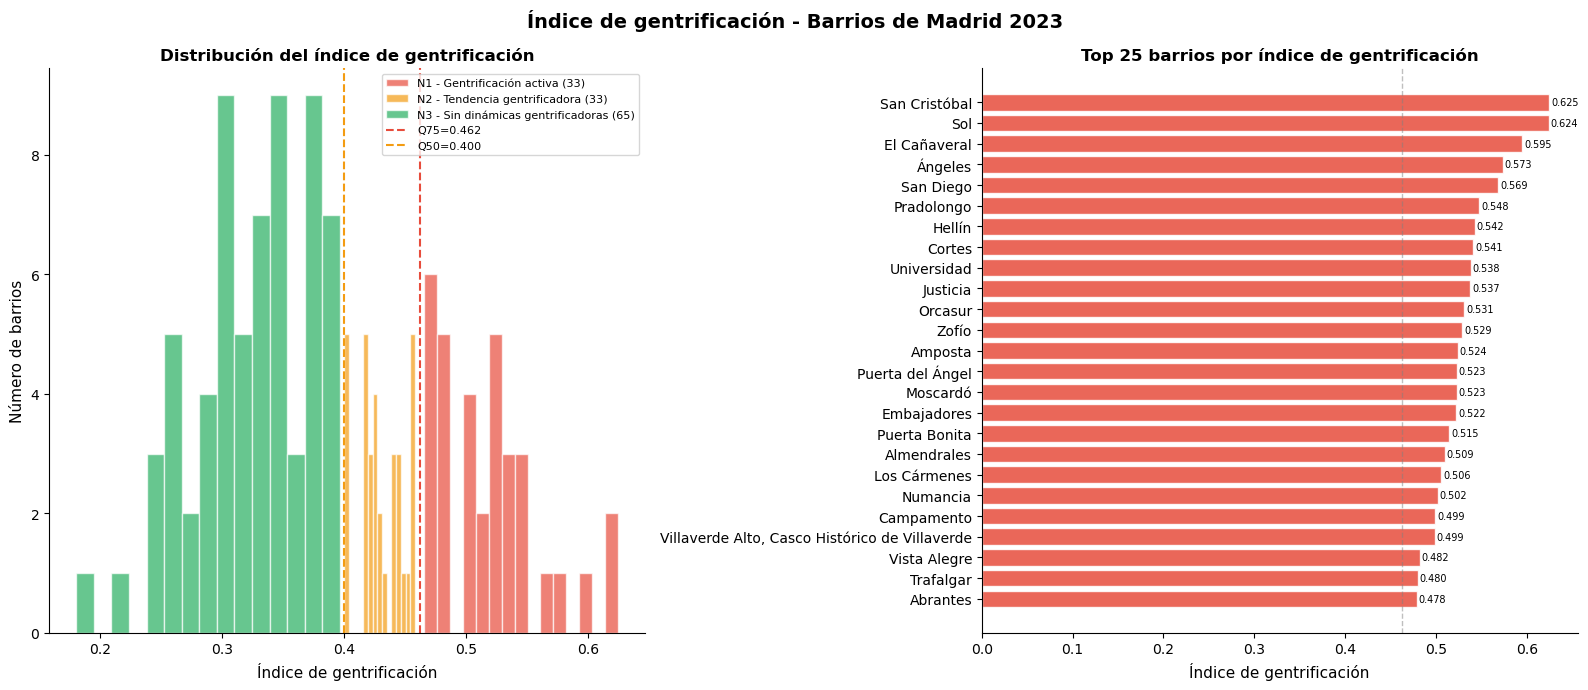

In [15]:
#Visualización del índice

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#Distribución del índice por nivel
colores_nivel = {
    'N1 - Gentrificación activa': '#E74C3C',
    'N2 - Tendencia gentrificadora': '#F39C12',
    'N3 - Sin dinámicas gentrificadoras': '#27AE60'}

for nivel, color in colores_nivel.items():
    datos = df_idx[df_idx['nivel_gentrificacion'] == nivel]['indice_gentrificacion']
    axes[0].hist(datos, bins=15, color=color, alpha=0.7, 
                 label=f'{nivel} ({len(datos)})', edgecolor='white')

axes[0].axvline(q75, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Q75={q75:.3f}')
axes[0].axvline(q50, color='#F39C12', linestyle='--', linewidth=1.5, label=f'Q50={q50:.3f}')
axes[0].set_xlabel('Índice de gentrificación', fontsize=11)
axes[0].set_ylabel('Número de barrios', fontsize=11)
axes[0].set_title('Distribución del índice de gentrificación', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

#Top 25 barrios
top25 = df_idx.sort_values('indice_gentrificacion', ascending=True).tail(25)
top25['nombre_corto'] = top25['barrio'].apply(lambda x: x.split('. ', 1)[1] if '. ' in x else x)
colores_barras = [colores_nivel[n] for n in top25['nivel_gentrificacion']]

axes[1].barh(
    top25['nombre_corto'],
    top25['indice_gentrificacion'],
    color=colores_barras,
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_xlabel('Índice de gentrificación', fontsize=11)
axes[1].set_title('Top 25 barrios por índice de gentrificación', fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].axvline(q75, color='gray', linestyle='--', linewidth=1, alpha=0.5)

#Añadimos valores
for i, (_, row) in enumerate(top25.iterrows()):
    axes[1].text(
        row['indice_gentrificacion'] + 0.002, i,
        f'{row["indice_gentrificacion"]:.3f}',
        va='center', fontsize=7)

plt.suptitle('Índice de gentrificación - Barrios de Madrid 2023', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'indice_gentrificacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#Guardar dataset

cols_guardar = [
    'cod_barrio', 'barrio', 'cluster', 'cluster_nombre',
    'dim_poblacion_extranjera', 'dim_poblacion_joven',
    'dim_hosteleria', 'dim_alquiler', 'dim_envejecimiento',
    'indice_gentrificacion', 'nivel_gentrificacion']

df_idx[cols_guardar].sort_values('indice_gentrificacion', ascending=False).to_csv(TABLES + 'indice_gentrificacion.csv', index=False)

In [17]:
#Cruzamos el clustering y el índice de gentrificación
print('Comparativa de clustering e índice\n')

for cluster in range(3):
    nombre = df_idx[df_idx['cluster'] == cluster]['cluster_nombre'].iloc[0]
    subset = df_idx[df_idx['cluster'] == cluster]
    total = len(subset)
    
    print(f'{nombre} ({total} barrios):')
    for nivel in ['N1 - Gentrificación activa', 
                  'N2 - Tendencia gentrificadora',
                  'N3 - Sin dinámicas gentrificadoras']:
        count = len(subset[subset['nivel_gentrificacion'] == nivel])
        print(f'  {nivel}: {count} barrios ({count/total*100:.1f}%)')
    print()

Comparativa de clustering e índice

Barrios consolidados y turísticos (20 barrios):
  N1 - Gentrificación activa: 9 barrios (45.0%)
  N2 - Tendencia gentrificadora: 10 barrios (50.0%)
  N3 - Sin dinámicas gentrificadoras: 1 barrios (5.0%)

Barrios en transformación (49 barrios):
  N1 - Gentrificación activa: 24 barrios (49.0%)
  N2 - Tendencia gentrificadora: 19 barrios (38.8%)
  N3 - Sin dinámicas gentrificadoras: 6 barrios (12.2%)

Barrios residenciales estables (62 barrios):
  N1 - Gentrificación activa: 0 barrios (0.0%)
  N2 - Tendencia gentrificadora: 4 barrios (6.5%)
  N3 - Sin dinámicas gentrificadoras: 58 barrios (93.5%)



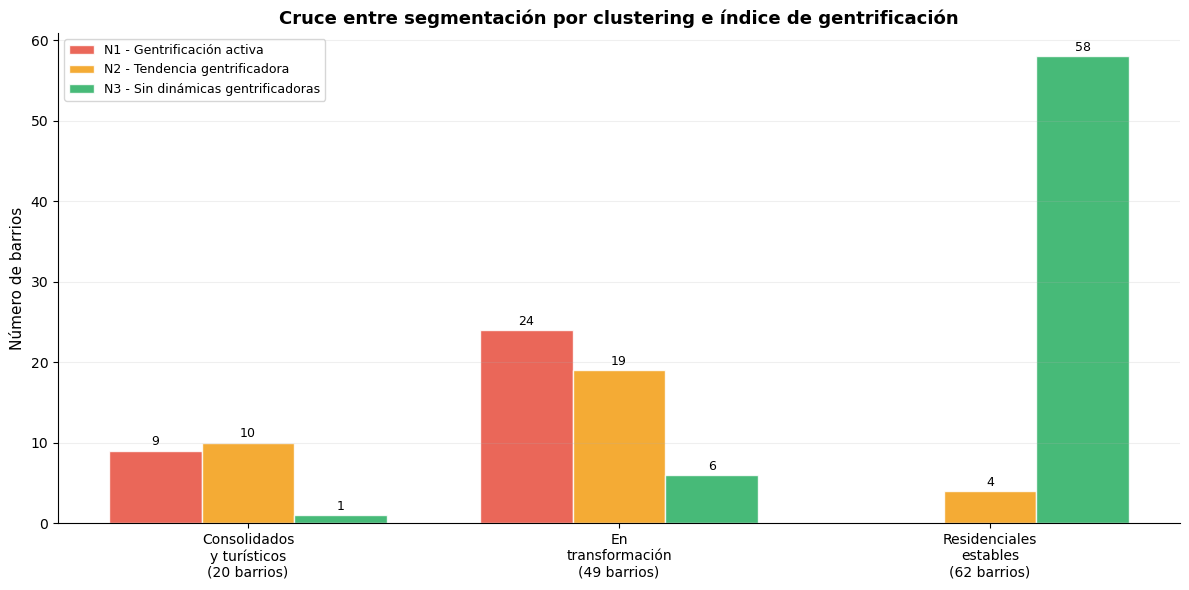

In [18]:
#Gráfico de cruce clustering vs índice
fig, ax = plt.subplots(figsize=(12, 6))

clusters_nombres = [
    'Consolidados\ny turísticos\n(20 barrios)','En\ntransformación\n(49 barrios)', 'Residenciales\nestables\n(62 barrios)']

n1_vals = [9, 24, 0]
n2_vals = [10, 19, 4]
n3_vals = [1, 6, 58]
x = np.arange(len(clusters_nombres))
width = 0.25
bars1 = ax.bar(x - width, n1_vals, width, label='N1 - Gentrificación activa', color='#E74C3C', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x, n2_vals, width, label='N2 - Tendencia gentrificadora', color='#F39C12', alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + width, n3_vals, width, label='N3 - Sin dinámicas gentrificadoras', color='#27AE60', alpha=0.85, edgecolor='white')

#Añadimos valores encima de las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                height + 0.3,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(clusters_nombres, fontsize=10)
ax.set_ylabel('Número de barrios', fontsize=11)
ax.set_title('Cruce entre segmentación por clustering e índice de gentrificación', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(FIGURES + 'cruce_clustering_indice.png', dpi=150, bbox_inches='tight')
plt.show()